### Universidade Federal do Piauí
**Projeto:** Redes Neurais para Inferência Diagnóstica em Dermatologia  Dados Clínicos e Imagem - HAM10000


---
# 📦 Importações, Instalações e Funções


---




## Instalações e Importações


Bloco inicial de instalação das bibliotecas. Essencial para garantir que o ambiente (como o Google Colab ou Kaggle) tenha todas as dependências necessárias para o projeto.

In [1]:
!pip install kaggle
!pip install tensorflow
!pip install albumentations
!pip install opencv-python-headless
!pip install efficientnet
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install seaborn
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.2 MB/s eta 0:00:00


In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
import cv2
import kagglehub
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from keras import backend as K

## Configurações Iniciais

In [3]:
# ----------------------
# Configurações principais
# ----------------------
IMG_SIZE = (320, 320)        # bom tamanho para capturar detalhes e ainda ser computacionalmente viável.
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

# ----------------------
# Albumentations (apenas no pipeline tf.data quando augment=True)
# ----------------------
transform = A.Compose([
    A.RandomResizedCrop(
        size=(IMG_SIZE[0], IMG_SIZE[1]),
        scale=(0.70, 1.00),
        ratio=(0.9, 1.1),
        p=0.6
    ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=25,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25,
        p=0.7
    ),

    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=15,
        val_shift_limit=10,
        p=0.3
    ),

    A.GaussianBlur(blur_limit=(3, 7), p=0.3),

    A.CoarseDropout( # (similar ao Cutout) ajuda a tornar a rede mais robusta a oclusões.
        max_holes=4,
        max_height=IMG_SIZE[0] // 10,
        max_width=IMG_SIZE[1] // 10,
        p=0.4
    ),
], p=1.0)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-368/3017808.py:46: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout( # (similar ao Cutout) ajuda a tornar a rede mais robusta a oclusões.


## Funções

In [4]:
def find_image_path(image_id, img_dirs, exts=['.jpg', '.JPG', '.jpeg', '.png']):
    for d in img_dirs:
        for ext in exts:
            p = d / (f"{image_id}{ext}")
            if p.exists():
                return str(p)
    return None

In [5]:
def augment_image_np(image_np):
    # Albumentations espera uint8 em geral; seu pipeline já normaliza depois.
    augmented = transform(image=image_np)
    return augmented['image'].astype(np.float32)

In [6]:
def load_and_preprocess_image(path, img_size=IMG_SIZE):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img

In [7]:
def path_label_to_dataset(paths, labels, batch_size=BATCH_SIZE, shuffle=True, augment=False):
    paths = [os.fspath(p) for p in paths]
    labels_enc = le.transform(labels)  # usa o LabelEncoder global 'le'
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_enc))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = img / 255.0  # normaliza aqui
        return img, tf.one_hot(label, num_classes)

    def _tf_augment(image, label):
        # tf.numpy_function recebe/retorna tensores numpy -> usa augment_image_np
        aug = tf.numpy_function(func=augment_image_np, inp=[tf.cast(image * 255.0, tf.uint8)], Tout=tf.float32)
        aug.set_shape(IMG_SIZE + (3,))
        aug = aug / 255.0  # garante normalização
        return aug, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_tf_augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [8]:
def multimodal_dataset(paths, clinical_features, labels, batch_size=BATCH_SIZE, shuffle=True, augment=False):
  """
  Retorna um tf.data.Dataset que emite: ((image, clinical_vector), one_hot_label)
  - paths: array-like de caminhos das imagens
  - clinical_features: array-like shape (n_samples, n_features) do tipo float32
  - labels: array-like de rótulos string (ex: 'mel', 'nv')
  """
  paths = [os.fspath(p) for p in paths]
  clinical = np.asarray(clinical_features, dtype=np.float32)
  labels_enc = le.transform(labels)

  ds = tf.data.Dataset.from_tensor_slices((paths, clinical, labels_enc))

  if shuffle:
    ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

  def _load(path, clin, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return (img, clin), tf.one_hot(label, num_classes)

  def _tf_augment(inputs, label):
    # inputs: (image, clin)
    img, clin = inputs
    # aplica augmentação somente na imagem usando numpy_function
    aug = tf.numpy_function(func=augment_image_np, inp=[tf.cast(img * 255.0, tf.uint8)], Tout=tf.float32)
    aug.set_shape(IMG_SIZE + (3,))
    aug = aug / 255.0
    return (aug, clin), label

  ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
  if augment:
    ds = ds.map(_tf_augment, num_parallel_calls=AUTOTUNE)

  ds = ds.batch(batch_size).prefetch(AUTOTUNE)
  return ds

In [9]:
def build_image_branch(input_shape):
    inp = layers.Input(shape=input_shape)

    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_tensor=inp
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.50)(x)

    return inp, x

def build_clinical_branch(n_features):
    inp = layers.Input(shape=(n_features,))
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(8, activation="relu")(x)
    return inp, x

In [10]:
def plot_training_history(history, phase_name):
    """
    Gera e salva gráficos de Acurácia e Perda (Loss) vs. Épocas para um objeto history do Keras.

    Args:
        history: Objeto History retornado por model.fit() da Keras.
        phase_name: Nome da fase de treinamento (e.g., 'Fase 1 - Estabilizacao').
    """

    # Verifica se os dados necessários estão no histórico (útil para debug)
    if 'accuracy' not in history.history:
        print("Erro: 'accuracy' não encontrado no objeto history.")
        return

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Configuração da Figura
    plt.figure(figsize=(14, 5))

    # Subplot 1: Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Acurácia de Treinamento')
    plt.plot(epochs, val_acc, 'r', label='Acurácia de Validação')
    plt.title(f'Acurácia de Treinamento e Validação ({phase_name})')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Perda (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Perda de Treinamento')
    plt.plot(epochs, val_loss, 'r', label='Perda de Validação')
    plt.title(f'Perda (Loss) de Treinamento e Validação ({phase_name})')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Otimização do layout e salvamento
    plt.tight_layout()
    filename = f'training_history_plot_{phase_name.replace(" ", "_").replace("-", "")}.png'
    plt.savefig(filename)
    plt.show() # Mostra o gráfico no notebook
    plt.close()

    print(f"\nGráfico de histórico salvo como {filename}")

In [11]:
def categorical_focal_loss(gamma=2.0, alpha=0.75):
    """
    Implementação da Categorical Focal Loss para Keras.
    Usa labels One-Hot (como esperado pela sua compilação).

    Args:
        gamma (float): Fator modulador que aumenta a perda de exemplos difíceis (padrão: 2.0).
        alpha (float): Fator de peso para classes, ajudando a equilibrar classes (padrão: 0.75).
    """
    def categorical_focal_loss_fixed(y_true, y_pred):
        # Garante estabilidade numérica
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1. - K.epsilon())

        # 1. Perda de Cross-Entropy (CE)
        cross_entropy = -y_true * tf.math.log(y_pred)

        # 2. Fator Modulador: (1 - p_t)^gamma
        # (p_t é a probabilidade do modelo para a classe correta)
        modulating_factor = tf.pow(1.0 - y_pred, gamma)

        # 3. Perda Focal: alpha * (1 - p_t)^gamma * CE
        focal_loss = alpha * modulating_factor * cross_entropy

        # Retorna a soma da perda focal sobre as classes
        return tf.reduce_sum(focal_loss, axis=-1)

    return categorical_focal_loss_fixed

## Acessar Conteúdo

In [12]:
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


---
#🕵 Coletar e demonstrar dados do dataset escolhido


## Carregando os Dados e Informações

Metadata carregado!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
Número de imagens encontradas: 10015


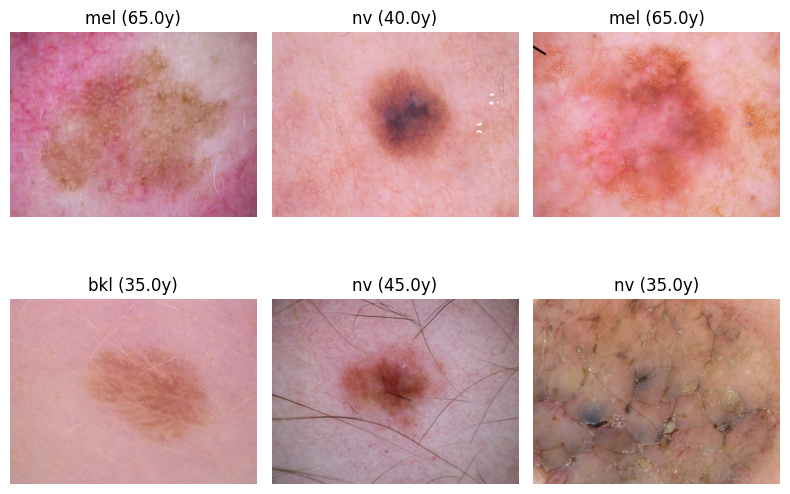

In [13]:
# Caminho base (diretório do dataset)
DATA_DIR = Path('/kaggle/input/skin-cancer-mnist-ham10000')

# O arquivo CSV está diretamente nesta pasta
METADATA_CSV = DATA_DIR / 'HAM10000_metadata.csv'

# As imagens estão divididas em duas pastas
IMG_DIRS = [
    DATA_DIR / 'HAM10000_images_part_1',
    DATA_DIR / 'HAM10000_images_part_2'
]

# Carregar o metadata
if METADATA_CSV.exists():
    meta = pd.read_csv(METADATA_CSV)
    print('Metadata carregado!')
    meta.info()
else:
    print('⚠️ METADATA_CSV não encontrado em', METADATA_CSV)

# Exibir algumas imagens de amostra
if 'meta' in globals():
    meta['image_path'] = meta['image_id'].apply(lambda x: find_image_path(x, IMG_DIRS))
    meta = meta[meta['image_path'].notna()].reset_index(drop=True)
    print('Número de imagens encontradas:', len(meta))
    sample = meta.sample(6, random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        image_id = row['image_id']

        # Buscar a imagem nas duas pastas
        img_path = None
        for d in IMG_DIRS:
            candidate = d / f"{image_id}.jpg"
            if candidate.exists():
                img_path = candidate
                break

        # Mostrar imagem se encontrada
        if img_path and img_path.exists():
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"{row.get('dx','')} ({row.get('age','?')}y)")
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Imagem não encontrada', ha='center', va='center')
            ax.axis('off')

    plt.tight_layout()

## Análise exploratória e identificação de outliers

In [14]:
# Estatística Básica
print("Estatísticas básicas do dataset")
meta.describe(include='all')

Estatísticas básicas do dataset


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
count,10015,10015,10015,10015,9958.000000,10015,10015,10015
unique,7470,10015,7,4,NaN,3,15,10015
top,HAM_0003789,ISIC_0032258,nv,histo,NaN,male,back,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
freq,6,1,6705,5340,NaN,5406,2192,1
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN,NaN


## Identificar e demonstrar outliers nos dados

### Age

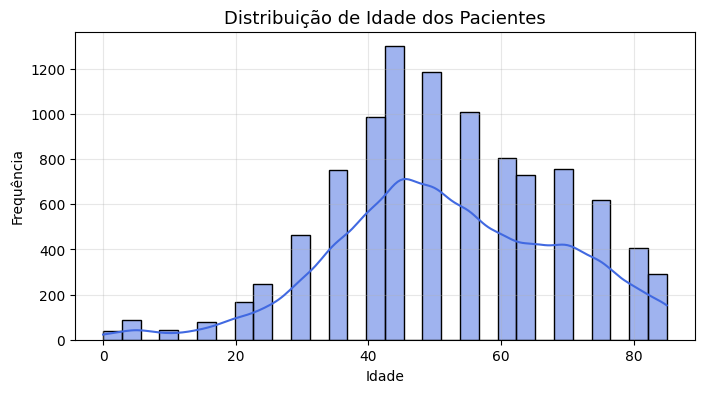

In [15]:
# DISTRIBUIÇÃO DE IDADES
if 'age' in meta.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(meta['age'].dropna(), bins=30, kde=True, color='royalblue')
    plt.title('Distribuição de Idade dos Pacientes', fontsize=13)
    plt.xlabel('Idade')
    plt.ylabel('Frequência')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("⚠️ Coluna 'age' não encontrada no dataset.")


Outliers de idade identificados: 39 registros


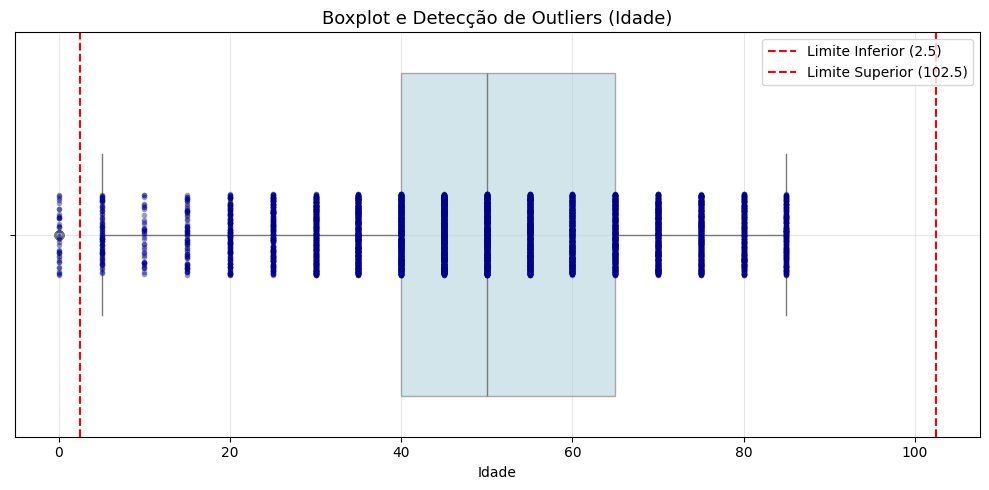

In [16]:
if 'age' in meta.columns:
    # Cálculo dos quartis e do intervalo interquartílico
    Q1 = meta['age'].quantile(0.25)
    Q3 = meta['age'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Identificação de outliers
    outliers = meta[(meta['age'] < lower) | (meta['age'] > upper)]
    print(f"\nOutliers de idade identificados: {len(outliers)} registros")

    # Visualização gráfica dos outliers
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        x=meta['age'],
        color='lightblue',
        fliersize=6,  # tamanho dos marcadores de outlier
        boxprops=dict(alpha=0.6)
    )
    sns.stripplot(
        x=meta['age'],
        color='darkblue',
        alpha=0.4,
        size=4,
        jitter=True
    )

    plt.axvline(lower, color='red', linestyle='--', label=f'Limite Inferior ({lower:.1f})')
    plt.axvline(upper, color='red', linestyle='--', label=f'Limite Superior ({upper:.1f})')
    plt.title('Boxplot e Detecção de Outliers (Idade)', fontsize=13)
    plt.xlabel('Idade')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Não é possível calcular outliers: coluna 'age' ausente.")

0 Anos são bebês ou adultos sem idade ?

Total de registros encontrados com idade = 0: 39
Exibindo as primeiras amostras:


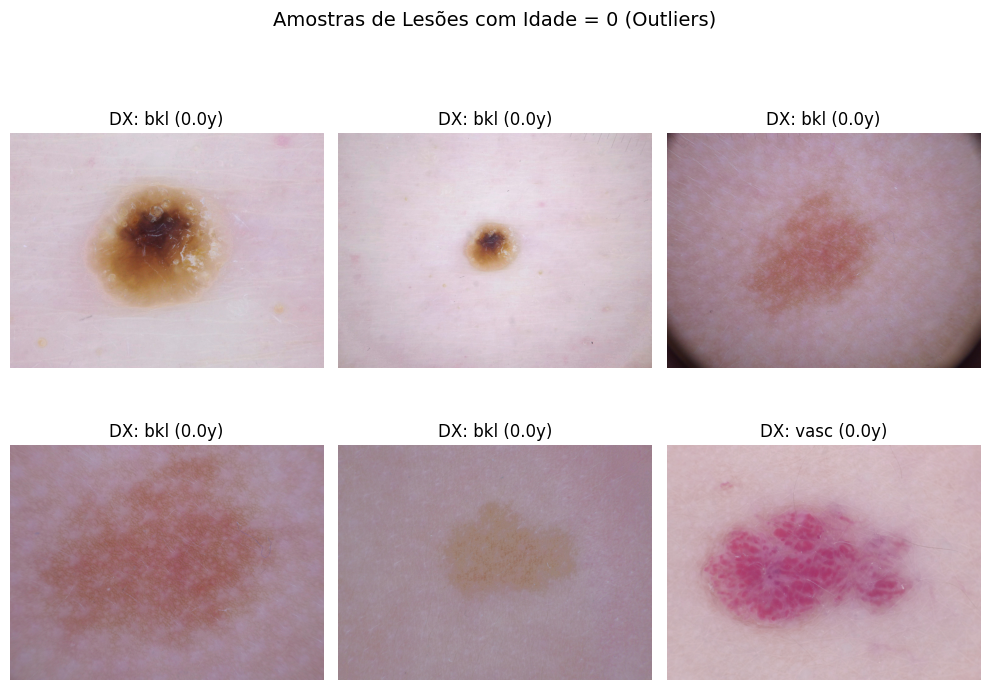

In [17]:
# Filtrar registros onde a idade é 0
outliers_0_anos = meta[meta['age'] == 0]

print(f"Total de registros encontrados com idade = 0: {len(outliers_0_anos)}")
print("Exibindo as primeiras amostras:")

# Selecionar até 6 amostras para visualização
# Usamos .head(6) para ver as primeiras
sample_outliers = outliers_0_anos.head(6)

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

# Iterar e plotar as imagens
for ax, (_, row) in zip(axes, sample_outliers.iterrows()):
    image_id = row['image_id']
    dx_label = row.get('dx', '?')
    age_value = row.get('age', '?')

    # Buscar o caminho da imagem usando a função definida
    img_path = find_image_path(image_id, IMG_DIRS)

    # Mostrar imagem se encontrada
    if img_path and Path(img_path).exists():
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"DX: {dx_label} ({age_value}y)")
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, 'Imagem não encontrada', ha='center', va='center')
        ax.axis('off')

# Ocultar eixos vazios se houver menos de 6 imagens
for i in range(len(sample_outliers), 6):
    fig.delaxes(axes[i])

plt.suptitle('Amostras de Lesões com Idade = 0 (Outliers)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta layout para o suptitle
plt.show()

**Validação dos Dados:** A visualização das imagens com age = 0 (e a presença de outras idades jovens no boxplot fora dos limites do IQR) confirmou que estes são, de fato, dados reais de lesões em bebês e crianças, e não erros de entrada ou datas "zoada" (como ano de nascimento ou data de aquisição).

**Natureza Estatística:** Embora 0 anos seja um outlier pelo critério estatístico do Boxplot (pois está muito distante do Q1), ele não é um outlier no sentido de ser um erro que distorce a realidade médica.

**Não é necessário remover esses registros.** Modelos de CNN e a futura abordagem multimodal precisam aprender sobre a variabilidade das lesões em todas as faixas etárias.

A idade é uma feature crucial no diagnóstico dermatológico (por exemplo, alguns tipos de nevos ou melanomas têm prevalência diferente em crianças vs. adultos). Ao manter a informação "0 anos", você está permitindo que o modelo aprenda padrões específicos associados a lesões em bebês.

**Conclusão:** Os outliers de idade são dados clinicamente válidos. Manter esses dados é a melhor estratégia para garantir que o modelo tenha capacidade preditiva no cenário real de triagem médica (objetivo principal do projeto), mesmo para os pacientes mais jovens.

### Sexo

Contagem de valores na coluna 'sex':
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


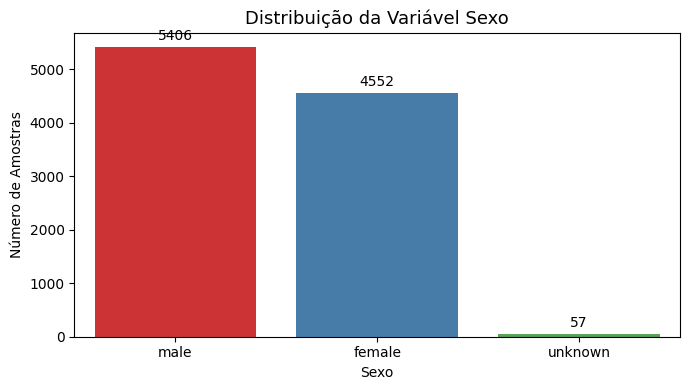

In [18]:
if 'sex' in meta.columns:
    print("Contagem de valores na coluna 'sex':")
    print(meta['sex'].value_counts())

    plt.figure(figsize=(7, 4))
    order = meta['sex'].value_counts().index.tolist()

    ax = sns.countplot(
        data=meta,
        x='sex',
        hue='sex',
        palette='Set1',
        legend=False,
        order=order
    )

    # Adiciona rótulos de valor acima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3)

    # Personalização do gráfico
    plt.title('Distribuição da Variável Sexo', fontsize=13)
    plt.xlabel('Sexo')
    plt.ylabel('Número de Amostras')
    plt.grid(False)  # remove o grid
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Coluna 'sex' não encontrada.")


Bom equilíbrio entre masculino e feminino e penas 0.6% “unknown” — pouco, mas precisa de decisão. A coluna sex não é usada diretamente no modelo, pois a rede aprende apenas com a imagem. Mas ela pode ser útil para análises de viés — por exemplo, se o modelo tem desempenho pior para um sexo... nesse caso, vou remover.

In [19]:
meta = meta[meta['sex'] != 'unknown'].copy()

### Diagnóstico

Categorias encontradas em meta['dx']: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
Contagem por dx:
 dx
nv       6658
mel      1113
bkl      1089
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


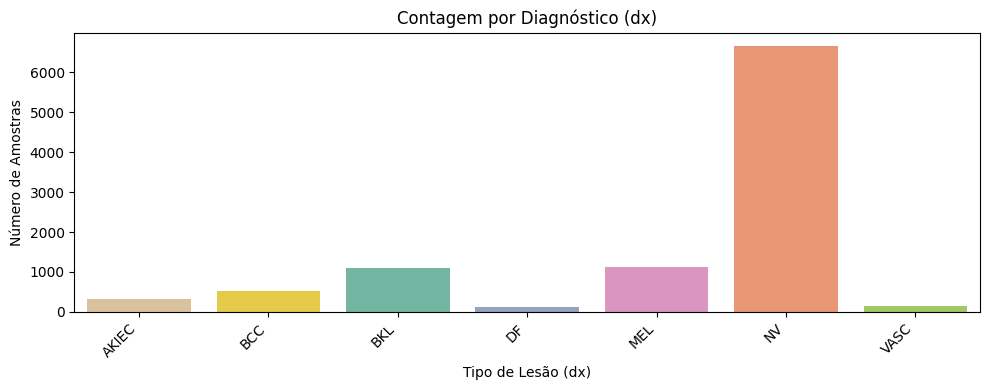

In [20]:
# checar categorias presentes (útil para depuração)
print("Categorias encontradas em meta['dx']:", meta['dx'].unique())
print("Contagem por dx:\n", meta['dx'].value_counts())

# dicionário de descrições
dx_labels = {
    "akiec": "Actinic Keratoses / Carcinoma Intraepitelial",
    "bcc":   "Basal Cell Carcinoma",
    "bkl":   "Benign Keratosis-like Lesions",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic Nevus",
    "vasc":  "Vascular Lesion"
}

dx_order = list(dx_labels.keys())  # ordem desejada

plt.figure(figsize=(10, 4))
sns.countplot(
    data=meta,
    x='dx',
    hue='dx',
    order=dx_order,
    palette='Set2',
    legend=False
)

plt.xticks(ticks=range(len(dx_order)), labels=[c.upper() for c in dx_order],
           rotation=45, ha='right')
plt.title('Contagem por Diagnóstico (dx)')
plt.xlabel('Tipo de Lesão (dx)')
plt.ylabel('Número de Amostras')
plt.tight_layout()
plt.show()


/tmp/ipython-input-368/495965886.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meta['dx'].value_counts().index,


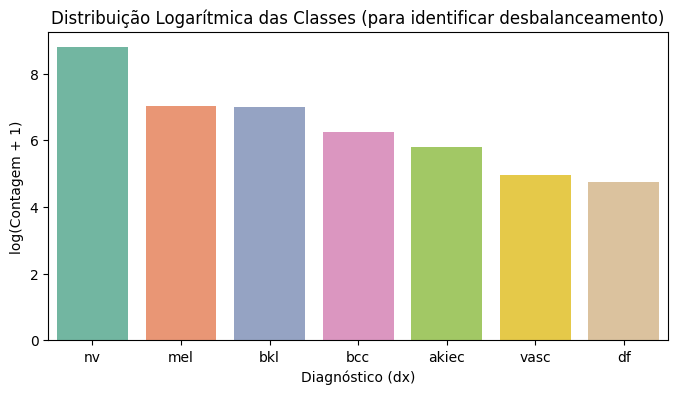

In [21]:
plt.figure(figsize=(8,4))
sns.barplot(x=meta['dx'].value_counts().index,
            y=np.log1p(meta['dx'].value_counts().values),
            palette='Set2')
plt.title('Distribuição Logarítmica das Classes (para identificar desbalanceamento)')
plt.xlabel('Diagnóstico (dx)')
plt.ylabel('log(Contagem + 1)')
plt.show()


Tecnicamente, não são outliers no sentido de valores anômalos, mas sim um desequilíbrio de classes (class imbalance). Contudo, podemos tratar esse excesso como um outlier na distribuição categórica e mudança de pesos.

---
# 🧱 Realizar todos os procedimentos cabíveis de pre-processamento dos dados


### Carregamento e Preparação do DataFrame

In [22]:
print(len(meta), "linhas no meta")

9958 linhas no meta


In [23]:
# Adicionar coluna com caminhos reais das imagens
meta['image_path'] = meta['image_id'].apply(lambda x: find_image_path(x, IMG_DIRS))

# Remover linhas com imagens não encontradas
meta = meta[meta['image_path'].notna()].reset_index(drop=True)
print("Número de imagens encontradas:", len(meta))


Número de imagens encontradas: 9958


### Pré-processamento clínico

In [24]:
# Features clínicas que vamos usar (exemplo): age, sex, localization
# Ajuste conforme colunas reais do seu CSV
USE_FEATURES = ['age', 'sex', 'localization']

if 'meta' in globals():
    # --- Age ---
    if 'age' in meta.columns:
      meta['age'] = meta['age'].replace('unknown', np.nan).astype(float)
      meta['age'] = meta['age'].fillna(meta['age'].median())
    else:
      a['age'] = meta.get('age', 0)

    # --- Sex --- (mapear para numérico)
    if 'sex' in meta.columns:
      # Normaliza strings (lower)
      meta['sex'] = meta['sex'].astype(str).str.lower()
      sex_map = {'male': 0, 'female': 1}
      # qualquer outro -> 2
      meta['sex'] = meta['sex'].map(sex_map).fillna(2).astype(int)
    else:
      meta['sex'] = 2


    # --- Localization --- (categórica -> codes)
    if 'localization' in meta.columns:
      meta['localization'] = meta['localization'].astype('category').cat.codes
    else:
      meta['localization'] = 0

    # --- Seleciona vetor clínico final e normaliza onde necessário ---
    clinical_df = meta[['age', 'sex', 'localization']].copy()

    # Normalização simples da idade (z-score) - evita escalas muito distintas
    if clinical_df['age'].std() > 0:
      clinical_df['age'] = (clinical_df['age'] - clinical_df['age'].mean()) / clinical_df['age'].std()
    clinical_array = clinical_df.values.astype(np.float32)

## Pré-processamento

In [25]:
# Preparar X, y (mantendo a lógica de rótulos)
if 'meta' in globals():
    X_img = meta['image_path'].values
    X_clin = clinical_array
    y = meta['dx'].values

    # Divisão em treino/val/test mantendo estratificação
    Ximg_train, Ximg_temp, Xclin_train, Xclin_temp, y_train, y_temp = train_test_split(
    X_img, X_clin, y, test_size=0.30, stratify=y, random_state=SEED)

    Ximg_val, Ximg_test, Xclin_val, Xclin_test, y_val, y_test = train_test_split(
    Ximg_temp, Xclin_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
    print(f'Treino: {len(Ximg_train)} | Validação: {len(Ximg_val)} | Teste: {len(Ximg_test)}')

    # Label encoding
    le = LabelEncoder()
    le.fit(y_train)
    num_classes = len(le.classes_)
    print('Classes:', le.classes_)

Treino: 6970 | Validação: 1494 | Teste: 1494
Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


## Cálculo de Pesos para Classes Desbalanceadas

In [26]:
# Pesos de classes
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=le.transform(y_train))
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print('Pesos de classe:', class_weight_dict)

Pesos de classe: {0: np.float64(4.348097317529632), 1: np.float64(2.765873015873016), 2: np.float64(1.3067116610423697), 3: np.float64(12.292768959435627), 4: np.float64(1.2781954887218046), 5: np.float64(0.2136725935009197), 6: np.float64(10.057720057720058)}


## Criar tf.data.Dataset pipelines

In [27]:
train_ds = multimodal_dataset(Ximg_train, Xclin_train, y_train, batch_size=BATCH_SIZE, shuffle=True, augment=True)
val_ds = multimodal_dataset(Ximg_val, Xclin_val, y_val, batch_size=BATCH_SIZE, shuffle=False, augment=False)
test_ds = multimodal_dataset(Ximg_test, Xclin_test, y_test, batch_size=BATCH_SIZE, shuffle=False, augment=False)

In [28]:
Xclin_train.shape[1]

3

---
# 🤖 Construindo o Modelo

### Construção da CNN

In [29]:
# ==============================================================================
# 1. CONSTRUÇÃO DO MODELO COM HEAD APRIMORADO (Ponto 1)
# ==============================================================================
# Assumindo que build_image_branch e build_clinical_branch estão definidas
image_in, image_feat = build_image_branch(IMG_SIZE + (3,))
clin_in, clin_feat = build_clinical_branch(Xclin_train.shape[1])

combined = layers.concatenate([image_feat, clin_feat])

# Head Aprimorado
z = layers.Dense(256, activation="relu", name="fused_dense_1")(combined)
z = layers.BatchNormalization(name="fused_bn_1")(z)
z = layers.Dropout(0.5, name="fused_dropout_1")(z)

z = layers.Dense(128, activation="relu", name="fused_dense_2")(z)
z = layers.Dropout(0.3, name="fused_dropout_2")(z)

out = layers.Dense(num_classes, activation="softmax", name="output_layer")(z)

model = tf.keras.Model(inputs=[image_in, clin_in], outputs=out)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### FASE 1: ESTABILIZAÇÃO DO HEAD (Backbone Congelado)

--- INICIANDO FASE 1 (FOCAL LOSS): ESTABILIZAÇÃO DO HEAD (LR: 1e-4) ---
Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.2297 - loss: 1.5684
Epoch 1: val_loss improved from inf to 0.73960, saving model to best_multimodal_model_effnet_FOCALLOSS.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 200s 672ms/step - accuracy: 0.2302 - loss: 1.5670 - val_accuracy: 0.6687 - val_loss: 0.7396 - learning_rate: 1.0000e-04
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.5217 - loss: 0.8595
Epoch 2: val_loss improved from 0.73960 to 0.52098, saving model to best_multimodal_model_effnet_FOCALLOSS.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 72s 330ms/step - accuracy: 0.5218 - loss: 0.8593 - val_accuracy: 0.6734 - val_loss: 0.5210 - learning_rate: 1.0000e-04
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.5785 - loss: 0.7478
Epoch 3: val_loss improved from 0.52098 to 0.50039, saving model to best_multimodal_model_effnet_FOCALLOSS.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 70s

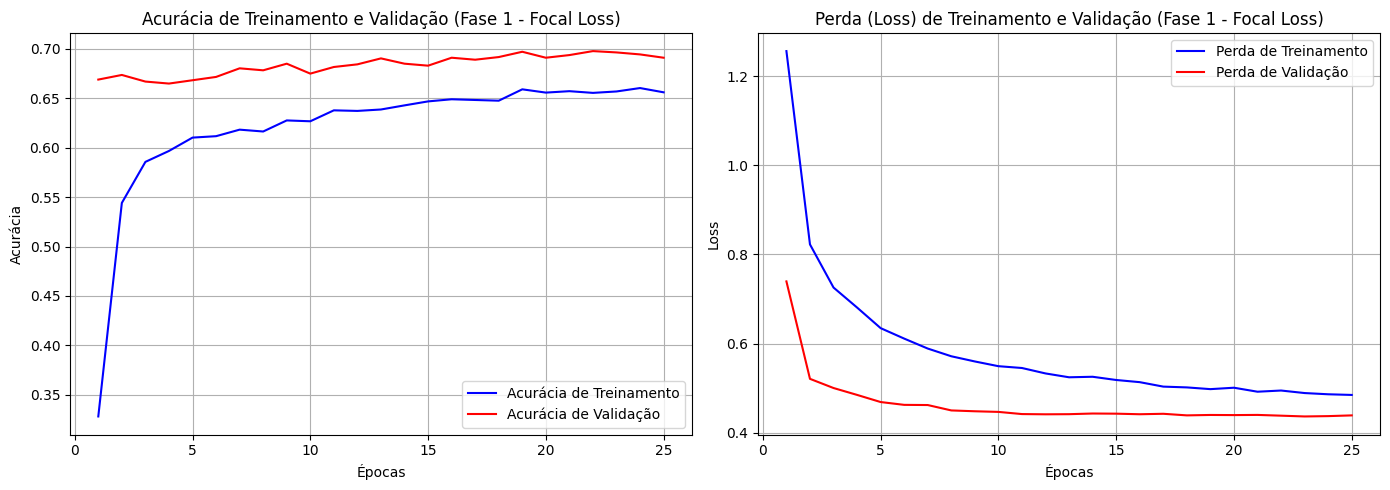


Gráfico de histórico salvo como training_history_plot_Fase_1__Focal_Loss.png


In [30]:
print("--- INICIANDO FASE 1 (FOCAL LOSS): ESTABILIZAÇÃO DO HEAD (LR: 1e-4) ---")

initial_lr = 1e-4
optimizer_fl = tf.keras.optimizers.Adam(learning_rate=initial_lr)

# Configurar o Backbone para a Fase 1 (Congelado)
for layer in model.layers:
    if 'block' in layer.name:
        layer.trainable = False
    elif 'fused' in layer.name or 'input_layer' in layer.name or 'output_layer' in layer.name:
        layer.trainable = True

# Compilar com Focal Loss (REMOVENDO class_weight_dict)
model.compile(
    optimizer=optimizer_fl,
    loss=categorical_focal_loss(gamma=2.0, alpha=0.75),
    metrics=["accuracy"]
)

callbacks_fl_phase1 = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_multimodal_model_effnet_FOCALLOSS.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    )
]

# Treinamento
history_fl = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    # class_weight=class_weight_dict, <-- Removido devido à Focal Loss
    callbacks=callbacks_fl_phase1
)
plot_training_history(history_fl, 'Fase 1 - Focal Loss')

### FASE 2: FINE-TUNING (Descongelamento de Camadas Finais)


--- INICIANDO FASE 2: FINE-TUNING SUPER LEVE (LR 1e-5) ---
Pesos da Fase 1 (FL) carregados com sucesso. Preparando Fine-Tuning.
Parâmetros treináveis APÓS ajuste (Bloco 7 + Head): 4,144,121
Epoch 26/35
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.6204 - loss: 0.6810
Epoch 26: val_loss improved from inf to 0.45684, saving model to best_multimodal_model_effnet_FASE3_FINAL.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 173s 543ms/step - accuracy: 0.6205 - loss: 0.6809 - val_accuracy: 0.6687 - val_loss: 0.4568 - learning_rate: 1.0000e-05
Epoch 27/35
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.6318 - loss: 0.6204
Epoch 27: val_loss improved from 0.45684 to 0.45546, saving model to best_multimodal_model_effnet_FASE3_FINAL.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 72s 331ms/step - accuracy: 0.6318 - loss: 0.6204 - val_accuracy: 0.6700 - val_loss: 0.4555 - learning_rate: 1.0000e-05
Epoch 28/35
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.6228 - loss: 0.6210
Epoch 28: val_los

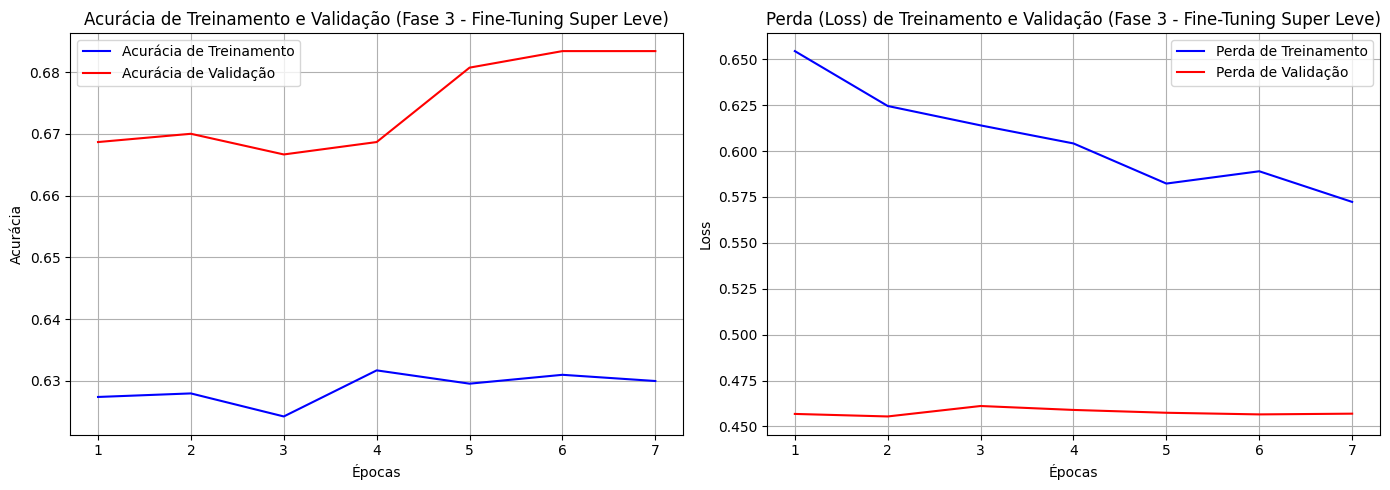


Gráfico de histórico salvo como training_history_plot_Fase_3__FineTuning_Super_Leve.png


In [31]:
print("\n--- INICIANDO FASE 2: FINE-TUNING SUPER LEVE (LR 1e-5) ---")

# 1. Carregar os MELHORES pesos da Fase 1 FL
try:
    model.load_weights('best_multimodal_model_effnet_FOCALLOSS.keras')
    print("Pesos da Fase 1 (FL) carregados com sucesso. Preparando Fine-Tuning.")
except:
    print("ERRO CRÍTICO: Não foi possível carregar o modelo. Pulando o Fine-Tuning.")

# 2. Descongelar APENAS o último bloco (Bloco 7)
set_trainable = False
for layer in model.layers:
    if 'block7' in layer.name: set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

# 3. Recompilar com LR MAIS ALTO (1e-5) e Focal Loss
fine_tune_lr_super_leve = 1e-5
optimizer_ft = tf.keras.optimizers.Adam(learning_rate=fine_tune_lr_super_leve)

model.compile(
    optimizer=optimizer_ft,
    loss=categorical_focal_loss(gamma=2.0, alpha=0.75),
    metrics=["accuracy"]
)

print(f"Parâmetros treináveis APÓS ajuste (Bloco 7 + Head): {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

# Callbacks Super Leves
callbacks_super_leve = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_multimodal_model_effnet_FASE3_FINAL.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    )
]

# 4. Treinamento
history_ft_final = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35, # Continua do 25
    initial_epoch=25,
    callbacks=callbacks_super_leve
)
plot_training_history(history_ft_final, 'Fase 3 - Fine-Tuning Super Leve')

## Salvando o Modelo e Histórico

In [32]:
# ==============================================================================
# BLOCO 1: CONEXÃO COM O GOOGLE DRIVE
# ==============================================================================
from google.colab import drive

# Monta o Drive. Você será solicitado a autorizar a conexão.
drive.mount('/content/drive')

# -----------------------------------------------------------------------------
# DEFINE O CAMINHO DA PASTA ONDE VOCÊ QUER SALVAR OS ARQUIVOS
# -----------------------------------------------------------------------------
DRIVE_PATH = '/content/drive/MyDrive/5º Período/ ML2/ Modelo'

# Cria a pasta se ela não existir
if not os.path.exists(DRIVE_PATH):
    os.makedirs(DRIVE_PATH)
    print(f"Pasta criada no Drive: {DRIVE_PATH}")
else:
    print(f"Pasta do Drive já existe: {DRIVE_PATH}")

print("\nDrive montado e caminho de salvamento definido.")

Mounted at /content/drive
Pasta do Drive já existe: /content/drive/MyDrive/5º Período/ ML2/ Modelo

Drive montado e caminho de salvamento definido.


### Avaliação final

Pesos do modelo final (best_multimodal_model_effnet_FASE3_FINAL.keras) carregados para avaliação.

✅ Acurácia de Validação Final: 0.6700

Relatório de Classificação (Validação Final):
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        49
         bcc     0.0000    0.0000    0.0000        77
         bkl     0.0000    0.0000    0.0000       163
          df     0.0000    0.0000    0.0000        17
         mel     0.2778    0.0299    0.0541       167
          nv     0.6748    0.9970    0.8048       999
        vasc     0.0000    0.0000    0.0000        22

    accuracy                         0.6700      1494
   macro avg     0.1361    0.1467    0.1227      1494
weighted avg     0.4823    0.6700    0.5442      1494



<Figure size 1000x1000 with 0 Axes>

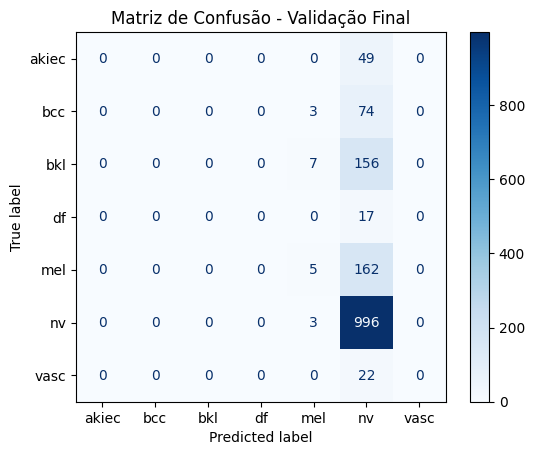

In [33]:
# =UC=============================================================================
# BLOCO 4: AVALIAÇÃO FINAL E SALVAMENTO NO DRIVE
# ==============================================================================
import pandas as pd # Necessário para salvar o histórico em CSV

# Carregar o melhor modelo (dá preferência ao Fase 3, se não, carrega o Fase 1 FL)
MODEL_SAVE_NAME = 'best_multimodal_model_effnet_FASE3_FINAL.keras'
FALLBACK_NAME = 'best_multimodal_model_effnet_FOCALLOSS.keras'

try:
    model.load_weights(MODEL_SAVE_NAME)
    print(f"Pesos do modelo final ({MODEL_SAVE_NAME}) carregados para avaliação.")
except:
    model.load_weights(FALLBACK_NAME)
    print(f"Pesos do modelo da Fase 1 FL ({FALLBACK_NAME}) carregados (Fase 3 não encontrou melhora).")


# --- AVALIAÇÃO ---
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"\n✅ Acurácia de Validação Final: {acc:.4f}")

# Geração do Relatório de Classificação
y_true = []
y_pred = []
for (X_batch, clin_batch), y_batch in val_ds:
    preds = model.predict([X_batch, clin_batch], verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_names = list(le.classes_)

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusão - Validação Final')


# --- RELATÓRIO FINAL ---
print('\nRelatório de Classificação (Validação Final):')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

In [34]:
# ==============================================================================
# >>> SALVAMENTO NO GOOGLE DRIVE <<<
# ==============================================================================

# 1. Salvar o Modelo (.keras)
FINAL_MODEL_PATH = os.path.join(DRIVE_PATH, 'modelo_multimodal_final.keras')
model.save(FINAL_MODEL_PATH)
print(f'\nModelo salvo em: {FINAL_MODEL_PATH}')

# 2. Salvar a Matriz de Confusão (.png)
CONFUSION_MATRIX_PATH = os.path.join(DRIVE_PATH, 'matriz_confusao_final.png')
plt.savefig(CONFUSION_MATRIX_PATH)
print(f'Matriz de Confusão salva em: {CONFUSION_MATRIX_PATH}')
plt.show() # Mostra o gráfico no output do Colab

# 3. Salvar o Histórico de Treinamento (Fase 3/Final) em CSV
# O objeto history_ft_final foi gerado na célula anterior.
try:
    hist_df = pd.DataFrame(history_ft_final.history)
    HISTORY_CSV_PATH = os.path.join(DRIVE_PATH, 'historico_treinamento_fase3.csv')
    hist_df.to_csv(HISTORY_CSV_PATH, index=False)
    print(f'Histórico (Fase 3) salvo em: {HISTORY_CSV_PATH}')
except NameError:
    print("Atenção: A variável 'history_ft_final' não foi encontrada. O CSV de histórico não foi salvo.")


Modelo salvo em: /content/drive/MyDrive/5º Período/ ML2/ Modelo/modelo_multimodal_final.keras
Matriz de Confusão salva em: /content/drive/MyDrive/5º Período/ ML2/ Modelo/matriz_confusao_final.png


<Figure size 640x480 with 0 Axes>

Histórico (Fase 3) salvo em: /content/drive/MyDrive/5º Período/ ML2/ Modelo/historico_treinamento_fase3.csv
